# SHAP Values for Different Model Types

This notebook demonstrates how to calculate and visualize SHAP values for different types of machine learning models:

- Binary classification
- Multiclass classification
- Regression

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score
from sklearn.datasets import load_breast_cancer, load_iris, fetch_california_housing

import shap

# Set random state for reproducibility
RANDOM_STATE = 42

## 1. Binary Classification Example

We'll use the breast cancer dataset as an example of binary classification.

In [33]:
# Load and prepare data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

# Train a classifier
model_binary = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
model_binary.fit(X_train, y_train)

# Evaluate the model
y_pred = model_binary.predict(X_test)
print(f"Binary classification accuracy: {accuracy_score(y_test, y_pred):.4f}")

Binary classification accuracy: 0.9708


### Calculate SHAP values for Binary Classification

In [34]:
# TreeExplainer is efficient for tree-based models like Random Forest
explainer = shap.TreeExplainer(model_binary)

# Calculate SHAP values for the test set
shap_explanation = explainer(X_test)
shap_values_binary = shap_explanation.values

# For binary classification with TreeExplainer, shap_values will return a list with one array
# for each class (sometimes just the positive class is returned)
print(f"Type of shap_values: {type(shap_values_binary)}")
if isinstance(shap_values_binary, list):
    print(f"Number of classes: {len(shap_values_binary)}")
    print(
        f"Shape of SHAP values for class 1: {shap_values_binary[1].shape if len(shap_values_binary) > 1 else shap_values_binary[0].shape}"
    )
else:
    print(f"Shape of SHAP values: {shap_values_binary.shape}")

Type of shap_values: <class 'numpy.ndarray'>
Shape of SHAP values: (171, 30, 2)


In [35]:
explainer.expected_value.shape

(2,)

In [36]:
shap_values_binary.shape

(171, 30, 2)

In [13]:
(
    type(shap_explanation.base_values),
    type(shap_explanation.data),
    type(shap_explanation.values),
    type(shap_explanation.feature_names),
    type(shap_explanation.output_names),
    # # Unknown
    # shap_explanation.output_indexes,
    # shap_explanation.lower_bounds,
    # shap_explanation.upper_bounds,
    # shap_explanation.error_std,
    # shap_explanation.main_effects,
    # shap_explanation.hierarchical_values,
    # shap_explanation.clustering,
    # Known
    shap_explanation.compute_time,
    # shap_explanation._s
)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, list, list, 0.03762626647949219)

### Visualize SHAP values for Binary Classification

<Figure size 1000x800 with 0 Axes>

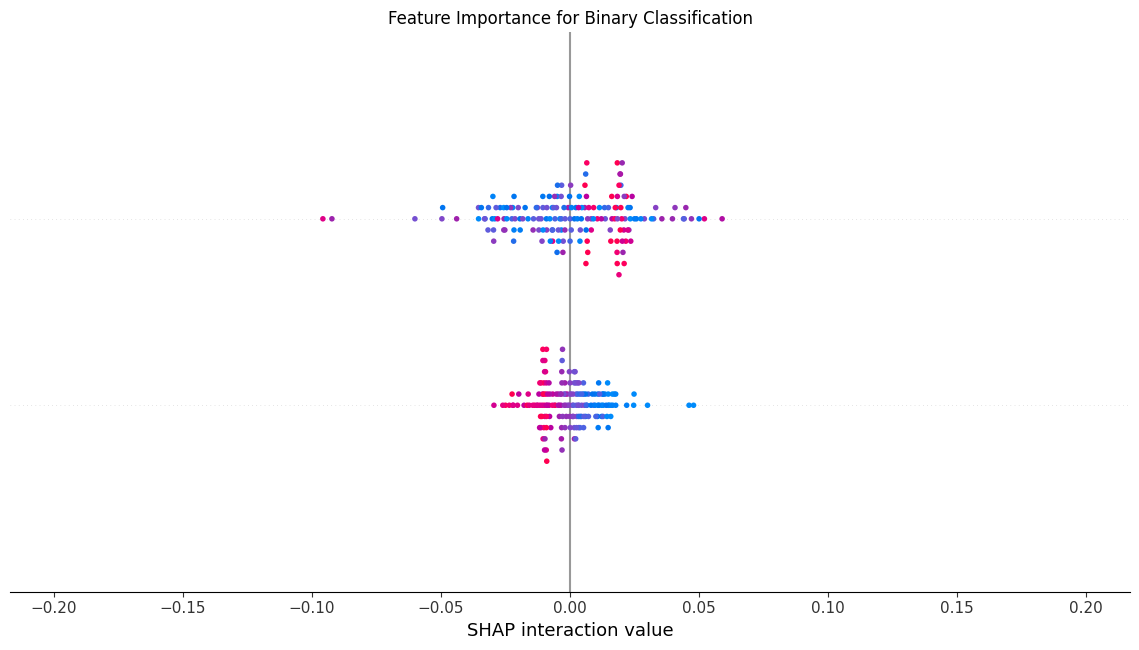

In [14]:
# Summary plot shows the most important features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_binary, X_test, plot_type="bar", show=False)
plt.title("Feature Importance for Binary Classification")
plt.tight_layout()
plt.show()

In [15]:
# SHAP values for one instance (example of first test instance)
plt.figure(figsize=(12, 4))
if isinstance(shap_values_binary, list) and len(shap_values_binary) > 1:
    # If we have two classes, use the positive class (index 1)
    shap.force_plot(
        explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        shap_values_binary[1][0] if len(shap_values_binary) > 1 else shap_values_binary[0],
        X_test.iloc[0],
        matplotlib=True,
        show=False,
    )
else:
    # If only one set of SHAP values is returned
    shap.force_plot(explainer.expected_value, shap_values_binary[0], X_test.iloc[0], matplotlib=True, show=False)
plt.title("SHAP Values for Single Instance (Binary Classification)")
plt.tight_layout()
plt.show()

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

<Figure size 1200x400 with 0 Axes>

## 2. Multiclass Classification Example

Using the Iris dataset for multiclass classification.

In [43]:
# Load and prepare data
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

# Train a classifier
model_multiclass = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
model_multiclass.fit(X_train, y_train)

# Evaluate the model
y_pred = model_multiclass.predict(X_test)
print(f"Multiclass classification accuracy: {accuracy_score(y_test, y_pred):.4f}")

Multiclass classification accuracy: 1.0000


### Calculate SHAP values for Multiclass Classification

In [44]:
# TreeExplainer is efficient for tree-based models
explainer = shap.TreeExplainer(model_multiclass)

# Calculate SHAP values for the test set
# shap_explanation = explainer(X_test)
# shap_values_binary = shap_explanation.values
shap_values_multiclass = explainer.shap_values(X_test)

# For multiclass, shap_values returns a list with one array per class
print(f"Type of shap_values: {type(shap_values_multiclass)}")
print(f"Number of classes: {len(shap_values_multiclass)}")
print(f"Shape of SHAP values for class 0: {shap_values_multiclass[:, :, 0].shape}")

Type of shap_values: <class 'numpy.ndarray'>
Number of classes: 45
Shape of SHAP values for class 0: (45, 4)


In [45]:
explainer.expected_value.shape

(3,)

In [46]:
shap_values_multiclass.shape

(45, 4, 3)

In [48]:
shap_explanation = explainer(X_test)

shap_explanation.base_values.shape

(45, 3)

In [ ]:
(
    type(shap_explanation.base_values),
    type(shap_explanation.data),
    type(shap_explanation.values),
    type(shap_explanation.feature_names),
    type(shap_explanation.output_names),
    # # Unknown
    # shap_explanation.output_indexes,
    # shap_explanation.lower_bounds,
    # shap_explanation.upper_bounds,
    # shap_explanation.error_std,
    # shap_explanation.main_effects,
    # shap_explanation.hierarchical_values,
    # shap_explanation.clustering,
    # Known
    shap_explanation.compute_time,
    # shap_explanation._s
)

### Visualize SHAP values for Multiclass Classification

In [ ]:
# Summary plot for all classes combined
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_multiclass, X_test, plot_type="bar", show=False)
plt.title("Feature Importance for All Classes (Multiclass)")
plt.tight_layout()
plt.show()

In [ ]:
# Class-specific summary plot (e.g., for class 0)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_multiclass[0], X_test, show=False)
plt.title("SHAP Values for Class 0 (Multiclass)")
plt.tight_layout()
plt.show()

In [ ]:
# Force plot for a single instance for a specific class (e.g., class 1)
plt.figure(figsize=(12, 4))
shap.force_plot(explainer.expected_value[1], shap_values_multiclass[1][0], X_test.iloc[0], matplotlib=True, show=False)
plt.title("SHAP Values for Single Instance, Class 1 (Multiclass)")
plt.tight_layout()
plt.show()

## 3. Regression Example

Using the California Housing dataset for regression.

In [49]:
# Load and prepare data
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Take a sample for faster computation
X_sample = X.sample(n=1000, random_state=RANDOM_STATE)
y_sample = y.loc[X_sample.index]

X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.3, random_state=RANDOM_STATE)

# Train a regressor
model_regression = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
model_regression.fit(X_train, y_train)

# Evaluate the model
y_pred = model_regression.predict(X_test)
print(f"Regression R² score: {r2_score(y_test, y_pred):.4f}")

Regression R² score: 0.6991


### Calculate SHAP values for Regression

In [50]:
# TreeExplainer for regression model
explainer = shap.TreeExplainer(model_regression)

# Calculate SHAP values for the test set
shap_values_regression = explainer.shap_values(X_test)

# For regression, shap_values returns a single array
print(f"Type of shap_values: {type(shap_values_regression)}")
print(f"Shape of SHAP values: {shap_values_regression.shape}")

Type of shap_values: <class 'numpy.ndarray'>
Shape of SHAP values: (300, 8)


In [52]:
shap_values_regression.size

2400

In [39]:
explainer.expected_value.shape

(1,)

In [40]:
shap_values_regression.shape

(300, 8)

In [41]:
explainer(X_test).values.shape

(300, 8)

In [42]:
explainer(X_test).base_values.shape

(300,)

### Visualize SHAP values for Regression

In [ ]:
# Summary plot for regression
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_regression, X_test, show=False)
plt.title("Feature Importance for Regression")
plt.tight_layout()
plt.show()

In [ ]:
# Dependency plot to show how a feature affects the prediction
plt.figure(figsize=(10, 6))
# Find the most important feature
feature_importance = np.abs(shap_values_regression).mean(axis=0)
most_important_feature_idx = np.argmax(feature_importance)
most_important_feature = X_test.columns[most_important_feature_idx]

shap.dependence_plot(most_important_feature, shap_values_regression, X_test, show=False)
plt.title(f"Dependence Plot for {most_important_feature}")
plt.tight_layout()
plt.show()

In [ ]:
# Force plot for a single instance
plt.figure(figsize=(12, 4))
shap.force_plot(explainer.expected_value, shap_values_regression[0], X_test.iloc[0], matplotlib=True, show=False)
plt.title("SHAP Values for Single Instance (Regression)")
plt.tight_layout()
plt.show()

## Advanced: Using KernelExplainer for non-tree models

For models that aren't tree-based (like neural networks or linear models), you can use the KernelExplainer.
This is a model-agnostic approach but is more computationally expensive.

In [ ]:
# Example using a simple linear model
from sklearn.linear_model import Ridge

# Train a linear model
linear_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
linear_model.fit(X_train, y_train)

# Create a KernelExplainer with a background dataset
# Using a small sample of the training data as background
background = shap.sample(X_train, 100)
kernel_explainer = shap.KernelExplainer(linear_model.predict, background)

# Calculate SHAP values for a few test instances (this can be slow)
# Using just 5 instances for demonstration
X_test_sample = X_test.iloc[:5]
kernel_shap_values = kernel_explainer.shap_values(X_test_sample)

# Visualize
plt.figure(figsize=(12, 4))
shap.force_plot(
    kernel_explainer.expected_value, kernel_shap_values[0], X_test_sample.iloc[0], matplotlib=True, show=False
)
plt.title("SHAP Values for Linear Model (KernelExplainer)")
plt.tight_layout()
plt.show()

## Conclusion

This notebook demonstrated how to calculate and visualize SHAP values for different types of machine learning models:

1. **Binary Classification**: Used the breast cancer dataset with RandomForestClassifier
2. **Multiclass Classification**: Used the iris dataset with RandomForestClassifier
3. **Regression**: Used the California housing dataset with RandomForestRegressor
4. **Advanced**: Used KernelExplainer for non-tree models

Key points to remember:

- For tree-based models (Random Forest, XGBoost, etc.), use TreeExplainer for efficient computation
- For non-tree models, use KernelExplainer (but be aware it's computationally expensive)
- The shape and structure of SHAP values varies by problem type:
  - Binary classification: List with one or two arrays (one per class)
  - Multiclass classification: List with one array per class
  - Regression: Single array of SHAP values